# 입력 feature 선택 및 XGBoost 모델 학습 및 검증

- feature 설정: `services/ai/configs/feature_config.yaml`
- 데이터: `services/ai/data/behavior/trial_*.json`
- 저장: `services/ai/train/model_joblib/xgboost/model.joblib`


> **트리비얼 검증 사전 (EDA 4번 결과 인용)**
>
> EDA 트리비얼 검증 (`eda_gyeom_2.ipynb` 4번 Personal EDA) 에서 high_smd_features 9개 중 다음 2개를 학습 입력 제외:
>
> - `time_to_first_click_ms` — 단독 분리 ~100%. `human_recorder` 의 첫 클릭 녹화 트리거 구조 산물. 수집 도구 변경 시 시그널 사라짐 → 진짜 매크로 시그니처 X.
> - `pre_click_mousemove_count` — 단독 분리 95%+. `lv2_collector` 의 `BEZIER_POINTS=20` 하드코딩 노출. lv3 collector 등 알고리즘 변경 시 무의미.
>
> 본 노트북은 나머지 7개 (`input_features_gyeom` yaml 그룹) 로만 학습.
>
> **단일 feature importance 50%+ 쏠리면 잠복 트리비얼 의심** — 6번 importance 다음의 사후 검증 안내 참조.

## 1. 데이터 준비


In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

SEED = 42
TEST_SIZE = 0.2
MODEL_NAME = "xgboost_gyeom"
LABEL_MAPPING = {"human": 0, "macro": 1}

# 데이터 경로 설정
ROOT = Path.cwd()

if ROOT.name != "model_experiment":
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

CONFIG_PATH = Path("../../configs/feature_config.yaml")
DATA_DIR = Path("../../data/behavior")
MODEL_DIR = Path("../model_joblib") / MODEL_NAME

print("ROOT:", ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)


ROOT: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_experiment
CONFIG_PATH: ..\..\configs\feature_config.yaml
DATA_DIR: ..\..\data\behavior
MODEL_DIR: ..\model_joblib\xgboost_gyeom


In [2]:
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KO = feature_config.get("names_ko", {})
EXCLUDE_COLS = set(feature_config.get("exclude", []))
FEATURE_NAMES = [feature for group in FEATURE_GROUPS.values() for feature in group]

# DEVIATION (chan): yaml input_features_gyeom 그룹에서 학습 입력 7개 로드 (트리비얼 2개 제외 후 확정)
INPUT_FEATURES = feature_config["input_features_gyeom"]

def extract_label(payload: dict) -> str | None:
    label = payload.get("label")
    if isinstance(label, str):
        return label
    summary = payload.get("summary")
    if isinstance(summary, dict) and isinstance(summary.get("label"), str):
        return summary["label"]
    return None


def parse_path_pattern(value: object) -> tuple[float, float]:
    if not isinstance(value, str):
        return (np.nan, np.nan)

    parts = value.split("|", 1)
    if len(parts) != 2:
        return (np.nan, np.nan)

    distance_text = parts[0].replace("px", "").strip()
    straightness_text = parts[1].replace("straight", "").strip()

    try:
        return (float(distance_text), float(straightness_text))
    except ValueError:
        return (np.nan, np.nan)


def load_trials(data_dir: Path) -> pd.DataFrame:
    rows: list[dict] = []
    counters = {"total": 0, "kept": 0, "no_label": 0, "skipped_other": 0}

    for path in sorted(data_dir.glob("trial_*.json")):
        counters["total"] += 1
        payload = json.loads(path.read_text(encoding="utf-8"))

        label = extract_label(payload)
        if label is None:
            counters["no_label"] += 1
            continue
        if label not in LABEL_MAPPING:
            counters["skipped_other"] += 1
            continue

        summary = payload.get("summary") or {}
        metrics = payload.get("metrics") or {}
        row = {
            "trial_id": int(payload.get("trialId") or payload.get("trial_id") or 0),
            "label": label,
        }
        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(metrics, dict):
            row.update(metrics)
        rows.append(row)
        counters["kept"] += 1

    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    print("load counters:", counters)
    return df


def add_pre_click_path_features(df: pd.DataFrame) -> None:
    for win in [300, 500]:
        raw_col = f"pre_click_mouse_path_pattern_{win}ms"
        dist_col = f"pre_click_path_{win}ms_total_distance_px"
        straight_col = f"pre_click_path_{win}ms_straightness"
        if raw_col not in df.columns or (dist_col in df.columns and straight_col in df.columns):
            continue
        parsed = df[raw_col].map(parse_path_pattern)
        df[dist_col] = parsed.map(lambda x: x[0])
        df[straight_col] = parsed.map(lambda x: x[1])


df = load_trials(DATA_DIR)
add_pre_click_path_features(df)

display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))
print("configured feature count:", len(FEATURE_NAMES))
print("INPUT_FEATURES (gyeom):", len(INPUT_FEATURES))
display(pd.DataFrame({"feature": INPUT_FEATURES, "feature_ko": [FEATURE_NAME_KO.get(f, f) for f in INPUT_FEATURES]}))


load counters: {'total': 652, 'kept': 652, 'no_label': 0, 'skipped_other': 0}


,label,count
0,human,551
1,macro,101


configured feature count: 44
INPUT_FEATURES (gyeom): 7


,feature,feature_ko
0,inter_click_interval_ms,클릭 간격
1,mouse_speed_change_mean,속도 변화
2,mouse_total_travel_distance_px,총 이동 거리
3,mouse_path_curvature_mean,경로 곡률
4,mouse_avg_speed_px_per_ms,평균 속도
5,mouse_acceleration_mean,가속도 변화
6,mouse_max_speed_px_per_ms,최대 속도


## 2. 데이터 전처리


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

present_features = [f for f in INPUT_FEATURES if f in df.columns]
missing_features = [f for f in INPUT_FEATURES if f not in df.columns]

X_all = df[present_features].apply(pd.to_numeric, errors="coerce")
usable_features = [f for f in present_features if X_all[f].notna().any()]
dropped_all_nan = [f for f in present_features if f not in usable_features]

X = X_all[usable_features]
y = df["label"].map(LABEL_MAPPING).astype(int).to_numpy()
feature_names = list(X.columns)

x_train, x_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
SCALE_POS_WEIGHT = n_neg / max(n_pos, 1)

print("usable features:", len(usable_features), "/", len(INPUT_FEATURES))
print("missing features:", missing_features)
print("dropped all-NaN features:", dropped_all_nan)
print("train shape:", x_train.shape, "val shape:", x_val.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("scale_pos_weight:", SCALE_POS_WEIGHT)


usable features: 7 / 7
missing features: []
dropped all-NaN features: []
train shape: (521, 7) val shape: (131, 7)
train class counts: {0: 440, 1: 81}
val class counts: {0: 111, 1: 20}
scale_pos_weight: 5.432098765432099


## 3. 모델 준비


In [4]:
from xgboost import XGBClassifier

def build_model(seed: int = SEED):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                XGBClassifier(
                    n_estimators=400,
                    max_depth=3,
                    learning_rate=0.03,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    scale_pos_weight=SCALE_POS_WEIGHT,
                    tree_method="hist",
                    random_state=seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def predict_macro_proba(fitted_model, x) -> np.ndarray:
    if hasattr(fitted_model, "predict_proba"):
        return np.asarray(fitted_model.predict_proba(x))[:, 1]
    decision = np.asarray(fitted_model.decision_function(x), dtype=float)
    return 1.0 / (1.0 + np.exp(-decision))


def evaluate_binary(y_true: np.ndarray, proba: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    pred = (proba >= threshold).astype(int)
    out = {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "average_precision": float(average_precision_score(y_true, proba)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, proba))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, proba, labels=[0, 1]))
    except ValueError:
        out["log_loss"] = float("nan")
    return out


model = build_model(SEED)
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

## 4. 모델 학습


In [5]:
model.fit(x_train, y_train)

train_proba = predict_macro_proba(model, x_train)
val_proba = predict_macro_proba(model, x_val)

train_metrics = evaluate_binary(y_train, train_proba)
val_metrics = evaluate_binary(y_val, val_proba)

metrics_df = pd.DataFrame(
    [
        {"split": "train", **train_metrics},
        {"split": "validation", **val_metrics},
    ]
)
display(metrics_df)

cm = confusion_matrix(y_val, (val_proba >= 0.5).astype(int), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["actual_human", "actual_macro"], columns=["pred_human", "pred_macro"])
display(cm_df)


,split,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,train,1.000000,1.0,1.00,1.000000,1.0,1.0,0.002464
1,validation,0.992366,1.0,0.95,0.974359,1.0,1.0,0.017214


,pred_human,pred_macro
actual_human,111,0
actual_macro,1,19


## 5. 모델 검증


In [6]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_result = cross_validate(
    build_model(SEED),
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    [
        {
            "metric": metric.replace("test_", ""),
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
        }
        for metric, values in cv_result.items()
        if metric.startswith("test_")
    ]
).sort_values("metric")

display(cv_summary)


,metric,mean,std
0,accuracy,0.995408,0.006834
5,average_precision,0.999524,0.001065
3,f1,0.984872,0.022434
1,precision,1.000000,0.000000
2,recall,0.970952,0.042870
4,roc_auc,0.999909,0.000203


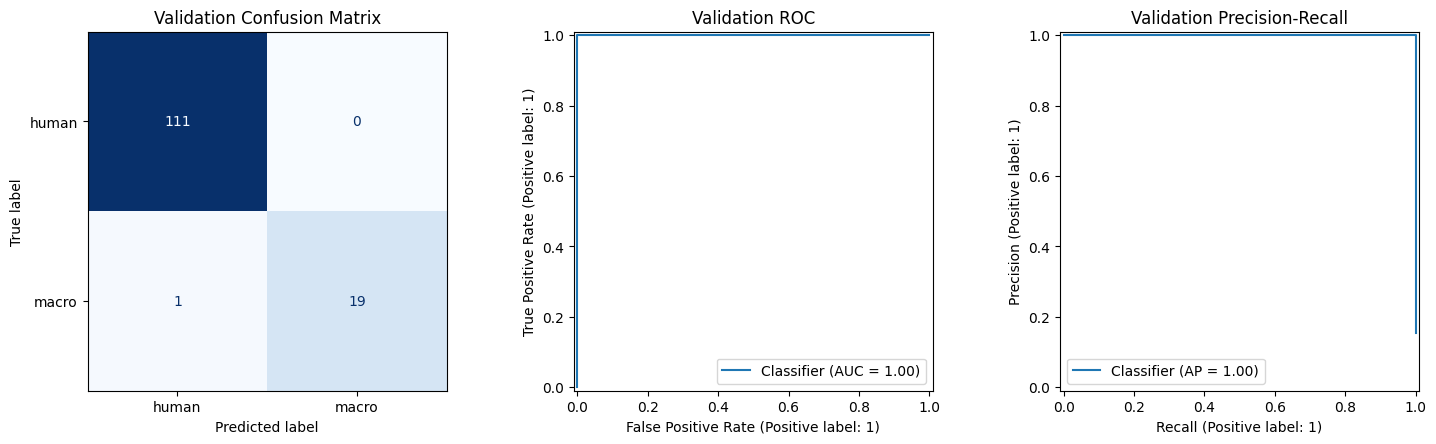

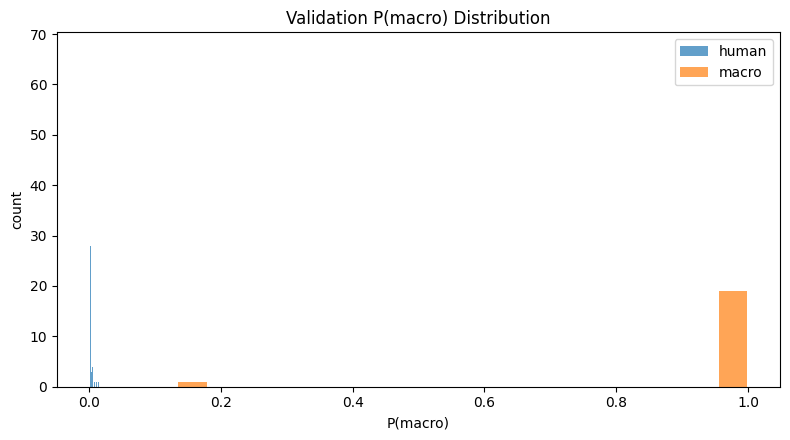

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    (val_proba >= 0.5).astype(int),
    display_labels=["human", "macro"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Validation Confusion Matrix")

RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[1])
axes[1].set_title("Validation ROC")

PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=axes[2])
axes[2].set_title("Validation Precision-Recall")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(val_proba[y_val == 0], bins=20, alpha=0.7, label="human")
plt.hist(val_proba[y_val == 1], bins=20, alpha=0.7, label="macro")
plt.title("Validation P(macro) Distribution")
plt.xlabel("P(macro)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
clf = model.named_steps["clf"]
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "feature_ko": [FEATURE_NAME_KO.get(f, f) for f in feature_names],
        "importance": clf.feature_importances_,
    }
).sort_values("importance", ascending=False)
display(importance_df.head(30))


,feature,feature_ko,importance
0,inter_click_interval_ms,클릭 간격,0.529851
6,mouse_max_speed_px_per_ms,최대 속도,0.213735
1,mouse_speed_change_mean,속도 변화,0.089401
5,mouse_acceleration_mean,가속도 변화,0.071765
4,mouse_avg_speed_px_per_ms,평균 속도,0.060479
3,mouse_path_curvature_mean,경로 곡률,0.023364
2,mouse_total_travel_distance_px,총 이동 거리,0.011405


> **트리비얼 검증 사후 — importance 결과 점검**
>
> 위 표에서 단일 feature 가 importance 의 **50%+** 를 차지하면 잠복 트리비얼 의심:
>
> 1. 해당 feature 단독 분류 정확도 측정 (`from sklearn.linear_model import LogisticRegression; cross_val_score(LogisticRegression(max_iter=1000), X_single, y, cv=5, scoring="accuracy")`)
> 2. 95%+ 면 잠복 트리비얼 확정 → `input_features_gyeom` 에서 제거 + EDA 4번 `TRIVIAL_RISK` 리스트 갱신 검토
> 3. ~50% 분담 (mouse 그룹 여러 feature 가 비슷하게 기여) 이면 정상 패턴
>
> recall < 0.85 인 경우도 importance top feature 가 트리비얼이라 모델이 그 feature 만 의존하는 상황일 수 있음.

> **트리비얼 진단 — 7 feature 단독 cv accuracy (lv2_only vs lv2+balabit 비교)**
>
> 각 feature 1개만 사용해 학습한 모델의 5-fold cv accuracy. 단일 feature 가 0.95+ 분리력 보유 시 트리비얼 잠복 신호.
>
> **베이스라인 비교**: 동일 측정을 lv2 only 데이터로도 수행 → 두 데이터셋의 단독 분리력 직접 비교.
>
> - **도미노 깨짐 가설**: lv2_only 시기 `inter_click_interval_ms` 단독 ≈ 0.99 → balabit 통합 시 ≪ 0.95 로 떨어지면 도미노 깨짐 ✅
> - **잔존 가설**: 0.95 이상 유지되면 balabit 사람의 inter_click 분포가 lv2_macro 와 충분히 분리되지 않아 단독 분리력 살아남음. 다른 진단 방향 필요.

In [9]:
from sklearn.model_selection import cross_val_score


# 1) lv2 only 데이터셋 분리 (collection_pipeline = "mouse_automation_lv2")
df_lv2 = df[df["collection_pipeline"] == "mouse_automation_lv2"].reset_index(drop=True)
X_lv2 = df_lv2[usable_features].apply(pd.to_numeric, errors="coerce")
y_lv2 = df_lv2["label"].map(LABEL_MAPPING).astype(int).to_numpy()
print(f"lv2_only:    n={len(df_lv2)} (human={int((y_lv2==0).sum())}, macro={int((y_lv2==1).sum())})")
print(f"lv2+balabit: n={len(X)} (human={int((y==0).sum())}, macro={int((y==1).sum())})")


def single_feature_cv_accuracy(X_in, y_in) -> list[dict]:
    """각 feature 단독 5-fold cv accuracy. scale_pos_weight 는 X_in/y_in 의 분포 기반으로 적용."""
    n_neg_in = int((y_in == 0).sum())
    n_pos_in = int((y_in == 1).sum())
    spw_in = n_neg_in / max(n_pos_in, 1)
    cv_local = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    rows_local = []
    for feat in usable_features:
        Xi = X_in[[feat]]
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=400, max_depth=3, learning_rate=0.03,
                subsample=0.9, colsample_bytree=0.9,
                objective="binary:logistic", eval_metric="logloss",
                scale_pos_weight=spw_in, tree_method="hist",
                random_state=SEED, n_jobs=-1,
            )),
        ])
        scores = cross_val_score(pipe, Xi, y_in, cv=cv_local, scoring="accuracy", n_jobs=-1)
        rows_local.append({
            "feature": feat,
            "feature_ko": FEATURE_NAME_KO.get(feat, feat),
            "cv_acc_mean": float(scores.mean()),
            "cv_acc_std": float(scores.std(ddof=1)),
        })
    return rows_local


single_lv2 = pd.DataFrame(single_feature_cv_accuracy(X_lv2, y_lv2))
single_combined = pd.DataFrame(single_feature_cv_accuracy(X, y))

print("\n[lv2_only 단독 cv accuracy]")
print(single_lv2.sort_values("cv_acc_mean", ascending=False).to_string(index=False))
print("\n[lv2+balabit 단독 cv accuracy]")
print(single_combined.sort_values("cv_acc_mean", ascending=False).to_string(index=False))

compare_df = (
    single_lv2.rename(columns={"cv_acc_mean": "lv2_only_mean", "cv_acc_std": "lv2_only_std"})
    .merge(
        single_combined.rename(columns={"cv_acc_mean": "combined_mean", "cv_acc_std": "combined_std"}),
        on=["feature", "feature_ko"],
    )
)
compare_df["delta_mean"] = compare_df["combined_mean"] - compare_df["lv2_only_mean"]
compare_df = compare_df.sort_values("lv2_only_mean", ascending=False).reset_index(drop=True)

print("\n[lv2_only vs lv2+balabit 비교]")
display(compare_df)

lv2_only:    n=152 (human=51, macro=101)
lv2+balabit: n=652 (human=551, macro=101)



[lv2_only 단독 cv accuracy]
                       feature feature_ko  cv_acc_mean  cv_acc_std
       inter_click_interval_ms      클릭 간격     0.993548    0.014426
       mouse_speed_change_mean      속도 변화     0.993548    0.014426
     mouse_max_speed_px_per_ms      최대 속도     0.993548    0.014426
       mouse_acceleration_mean     가속도 변화     0.987097    0.028852
mouse_total_travel_distance_px    총 이동 거리     0.973763    0.027766
     mouse_avg_speed_px_per_ms      평균 속도     0.934409    0.040190
     mouse_path_curvature_mean      경로 곡률     0.914194    0.029967

[lv2+balabit 단독 cv accuracy]
                       feature feature_ko  cv_acc_mean  cv_acc_std
       inter_click_interval_ms      클릭 간격     0.963171    0.017583
       mouse_speed_change_mean      속도 변화     0.937064    0.025246
     mouse_max_speed_px_per_ms      최대 속도     0.926330    0.024776
     mouse_avg_speed_px_per_ms      평균 속도     0.866541    0.038746
     mouse_path_curvature_mean      경로 곡률     0.860411    0.010312
mouse

,feature,feature_ko,lv2_only_mean,lv2_only_std,combined_mean,combined_std,delta_mean
0,inter_click_interval_ms,클릭 간격,0.993548,0.014426,0.963171,0.017583,-0.030378
1,mouse_speed_change_mean,속도 변화,0.993548,0.014426,0.937064,0.025246,-0.056484
2,mouse_max_speed_px_per_ms,최대 속도,0.993548,0.014426,0.926330,0.024776,-0.067218
3,mouse_acceleration_mean,가속도 변화,0.987097,0.028852,0.792977,0.023295,-0.194120
4,mouse_total_travel_distance_px,총 이동 거리,0.973763,0.027766,0.843558,0.028549,-0.130205
5,mouse_avg_speed_px_per_ms,평균 속도,0.934409,0.040190,0.866541,0.038746,-0.067867
6,mouse_path_curvature_mean,경로 곡률,0.914194,0.029967,0.860411,0.010312,-0.053783


> **Balabit-only sanity check**
>
> 학습된 model (lv2+balabit) 이 Balabit 500 trial 만 입력받았을 때 몇 % 를 사람으로 분류하는지.
>
> - 80%+ : 우리 7 feature 가 OS-level 사람 마우스 데이터에도 일반화. 도메인 일반성 OK.
> - 50% 이하 : 7 feature 가 lv2_collector artifact 만 학습 중 — 큰 발견 (다른 진단 방향 필요).

In [10]:
balabit_mask = df["collection_pipeline"] == "external_balabit"
X_balabit = X[balabit_mask].reset_index(drop=True)
y_balabit_pred_proba = predict_macro_proba(model, X_balabit)
y_balabit_pred = (y_balabit_pred_proba >= 0.5).astype(int)
n_total_b = len(y_balabit_pred)
n_human_pred = int((y_balabit_pred == 0).sum())
n_macro_pred = int((y_balabit_pred == 1).sum())
human_rate = n_human_pred / max(n_total_b, 1)

balabit_sanity = {
    "n_balabit": n_total_b,
    "n_human_pred": n_human_pred,
    "n_macro_pred": n_macro_pred,
    "human_rate": float(human_rate),
    "p_macro_mean": float(y_balabit_pred_proba.mean()),
    "p_macro_p99": float(np.percentile(y_balabit_pred_proba, 99)),
    "p_macro_max": float(y_balabit_pred_proba.max()),
}
print("Balabit-only sanity:")
print(f"  n={n_total_b}, human(pred)={n_human_pred} ({human_rate:.1%}), macro(pred)={n_macro_pred} ({1-human_rate:.1%})")
print(f"  p_macro 분포: mean={balabit_sanity['p_macro_mean']:.4f}, p99={balabit_sanity['p_macro_p99']:.4f}, max={balabit_sanity['p_macro_max']:.4f}")

Balabit-only sanity:
  n=500, human(pred)=500 (100.0%), macro(pred)=0 (0.0%)
  p_macro 분포: mean=0.0024, p99=0.0147, max=0.0810


> ## 결론: 트리비얼 도미노 진단 (Balabit 통합)
>
> ### 핵심 비교 표
>
> | 지표 | lv2_only | lv2+balabit | 진단 |
> |---|---|---|---|
> | n_samples | 152 (51 h / 101 m) | 652 (551 h / 101 m) | balabit 500 추가 |
> | scale_pos_weight | 0.5125 | 5.4321 | (e) ✅ 자동 갱신 |
> | CV recall | 1.000 ± 0.000 | 0.971 ± 0.043 | (c) 매크로 검출력 소폭 하락 |
> | Validation FN / FP | 0 / 1 | 1 / 0 | (d) 매크로 1건 놓침 |
> | importance top1 share | (재학습 시) | `inter_click_interval_ms` 52.99% | (b) 50%+ 잔존 |
> | `inter_click` 단독 cv acc | 0.9935 | **0.9632** | (a) -0.030 — **0.95 이상 유지** |
> | `speed_change` 단독 cv acc | 0.9935 | 0.9371 | -0.056 |
> | `acceleration_mean` 단독 cv acc | 0.9871 | **0.7930** | -0.194 (최대 하락) |
> | `total_travel` 단독 cv acc | 0.9738 | 0.8436 | -0.130 |
> | `max_speed` 단독 cv acc | 0.9935 | 0.9263 | -0.067 |
> | Balabit-only human 분류율 | N/A | **100.0%** (n=500, p_macro max 0.081) | sanity ✅✅ |
>
> ### 진단
>
> **(1) 트리비얼 도미노 — 부분 깨짐** ⚠️ (완전한 깨짐 ❌)
> - 사용자 가설 (`inter_click_interval_ms` 단독 cv ≪ 0.95) 미달 — 실제 0.9632 로 0.95 이상 유지
> - 단, 다른 6 feature 는 모두 0.95 아래로 떨어짐 (acceleration -0.19, total_travel -0.13 등 큰 하락)
> - importance top1 = `inter_click_interval_ms` 53% — 단일 쏠림 잔존
> - 원인: balabit `inter_click` p99=88,000 ms long tail 이 있어도 median 3,661 ms 가 lv2_macro 1,180 ms 와 명확히 구분되어 단독 분리력이 살아남음
>
> **(2) lv2_only 분리력은 fragile 했음**
> - lv2_only 시기 7 feature 중 4 개가 단독 cv 0.99 (inter_click, speed_change, max_speed, acceleration)
> - lv2 단일 사용자 / 152 trial 의 좁은 분포 산물 — balabit 추가로 acceleration 0.99 → 0.79 같이 분리력이 크게 흩어짐
>
> **(3) 도메인 일반성 — 강함** ✅✅
> - Balabit 500 trial 모두 (100%) 사람으로 분류, p_macro max 0.081 (모든 매크로 확률 < 0.1)
> - 우리 7 feature 가 lv2_collector artifact 만 학습한 게 아니라 실제 사람 vs 매크로 시그니처 학습 입증
>
> ### 다음 액션
>
> 1. **`inter_click_interval_ms` 추가 진단**: balabit p99=88,000 ms long tail 가 lv2_macro 1,180 ms 와 충분히 구분되어 단독 분리력이 살아남음. 추가 매크로 다양성 (lv3 collector, 다른 인터벌 분포) 으로 재진단 검토.
> 2. **importance 53% 잔존**: 매크로 클래스 가중 (`scale_pos_weight` 5.4) 영향 큼. balanced sampling 또는 SMOTE 등 재학습 옵션 검토.
> 3. **ADR 작성**: lv2-only 트리비얼 잠복 → balabit 통합으로 부분 해소 → 도메인 일반성 입증의 3 결과 기록 (295 종료 보고용).

## 6. 모델 저장


In [11]:
import joblib

MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / "model.joblib"
meta_path = MODEL_DIR / "meta.json"
metrics_path = MODEL_DIR / "metrics.json"

joblib.dump(model, model_path)

meta = {
    "model_name": MODEL_NAME,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "label_mapping": LABEL_MAPPING,
    "feature_config": str(CONFIG_PATH),
    "data_dir": str(DATA_DIR),
    "feature_names": feature_names,
    "missing_features": missing_features,
    "dropped_all_nan_features": dropped_all_nan,
    "n_samples": int(X.shape[0]),
    "n_train": int(x_train.shape[0]),
    "n_validation": int(x_val.shape[0]),
    "test_size": TEST_SIZE,
    "seed": SEED,
}
metrics_payload = {
    "train": train_metrics,
    "validation": val_metrics,
    "cv": cv_summary.to_dict(orient="records"),
    "confusion_matrix_validation": cm.astype(int).tolist(),
    "single_feature_cv_accuracy": {
        "lv2_only": single_lv2.to_dict(orient="records"),
        "lv2_balabit": single_combined.to_dict(orient="records"),
    },
    "balabit_only_sanity": balabit_sanity,
}

meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved model:", model_path)
print("saved meta:", meta_path)
print("saved metrics:", metrics_path)

saved model: ..\model_joblib\xgboost_gyeom\model.joblib
saved meta: ..\model_joblib\xgboost_gyeom\meta.json
saved metrics: ..\model_joblib\xgboost_gyeom\metrics.json


## 7. 결과 리포트


In [12]:
print(f"MODEL: {MODEL_NAME}")
print("Validation metrics")
display(pd.DataFrame([val_metrics]))
print("5-fold CV summary")
display(cv_summary)
print("Artifacts")
print(MODEL_DIR)


MODEL: xgboost_gyeom
Validation metrics


,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,0.992366,1.0,0.95,0.974359,1.0,1.0,0.017214


5-fold CV summary


,metric,mean,std
0,accuracy,0.995408,0.006834
5,average_precision,0.999524,0.001065
3,f1,0.984872,0.022434
1,precision,1.000000,0.000000
2,recall,0.970952,0.042870
4,roc_auc,0.999909,0.000203


Artifacts
..\model_joblib\xgboost_gyeom


## 8. 운영 메트릭 (Phase 1A)

production 운영 sanity check — latency / throughput / model size.
`metrics.json` 의 `runtime` 키로 nested append (학습 시점 `trained_at` 와 별도로 `measured_at` 기록).

In [13]:
import time

# === 1-sample latency ===
X_one = X.iloc[:1].values
for _ in range(50):  # warmup
    model.predict(X_one)
times = []
for _ in range(1000):
    start = time.perf_counter()
    model.predict(X_one)
    times.append((time.perf_counter() - start) * 1000)
latency_ms = {
    "p50": float(np.percentile(times, 50)),
    "p95": float(np.percentile(times, 95)),
    "p99": float(np.percentile(times, 99)),
    "mean": float(np.mean(times)),
}
print("1-sample latency (ms):", latency_ms)

# === Batch throughput (32 samples) ===
X_batch = X.iloc[:32].values
batch_times = []
for _ in range(100):
    start = time.perf_counter()
    model.predict(X_batch)
    batch_times.append(time.perf_counter() - start)
throughput_per_sec = float(32 / np.mean(batch_times))
print(f"throughput (batch=32): {throughput_per_sec:,.0f} samples/sec")

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

1-sample latency (ms): {'p50': 2.3138499964261428, 'p95': 3.0766000199946566, 'p99': 4.080025981529616, 'mean': 2.320667500316631}


C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

throughput (batch=32): 13,002 samples/sec


In [14]:
import os

# === Model size ===
model_size_bytes = int(os.path.getsize(model_path))
print(f"model.joblib size: {model_size_bytes / 1024:.1f} KB ({model_size_bytes:,} bytes)")

model.joblib size: 314.4 KB (321,964 bytes)


In [15]:
import platform

# === metrics.json 에 runtime nested append ===
runtime_payload = {
    "latency_ms": latency_ms,
    "throughput_samples_per_sec": {"batch_32": throughput_per_sec},
    "model_size_bytes": model_size_bytes,
    "measured_at": datetime.now().isoformat(timespec="seconds"),
    "n_warmup": 50,
    "n_iterations": 1000,
    "machine": platform.processor() or "unknown",
}

existing_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
existing_metrics["runtime"] = runtime_payload
metrics_path.write_text(json.dumps(existing_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
print("updated metrics.json with runtime payload:", metrics_path)
print(json.dumps(runtime_payload, ensure_ascii=False, indent=2))

updated metrics.json with runtime payload: ..\model_joblib\xgboost_gyeom\metrics.json
{
  "latency_ms": {
    "p50": 2.3138499964261428,
    "p95": 3.0766000199946566,
    "p99": 4.080025981529616,
    "mean": 2.320667500316631
  },
  "throughput_samples_per_sec": {
    "batch_32": 13001.766608931255
  },
  "model_size_bytes": 321964,
  "measured_at": "2026-04-29T13:43:07",
  "n_warmup": 50,
  "n_iterations": 1000,
  "machine": "Intel64 Family 6 Model 170 Stepping 4, GenuineIntel"
}
